# Supplementary Material 1
[Article Title Here]

Submitted to: [Journal Name Here]

Jorge Lizarazo¹, Gustavo A. Londoño², Judit Ungvari Martin³ ⁴, Justin Baldwin⁵ & Scott K. Robinson⁶

¹ Center for Animals on the Move, Department of Biology, Western University, London, ON, Canada
² Department of Biological Sciences, Bioprocesses and Biotechnology, Icesi University, Cali, Colombia
³ Future Earth Global Secretariat, New York, NY, USA
⁴ Institute for a Sustainable Earth, George Mason University, Fairfax, VA, USA
⁵ Department of Ecology and Evolutionary Biology, University of California, Santa Cruz, USA
⁶ Florida Museum of Natural History, University of Florida, Gainesville, Florida, USA

Corresponding authors:

Jorge Lizarazo  Jorge.lizarazo.b@gmail.com &
Gustavo A. Londoño  galondono@icesi.edu.co

This presents detailed statistical analyses examining seasonal variation in reproductive traits, including nest height, nest material composition, clutch size, and egg mass in Northern Mockingbird (*Mimus polyglottos*). We applied generalized linear models and mixed-effects models to evaluate month-level effects, interaction terms, and model assumptions, and provide additional diagnostic figures and post-hoc comparisons supporting the main manuscript results.


This notebook walks through the height, nest-weight, and egg-mass datasets, describing how each CSV is cleaned, how months are ordered, and how the GLMs diagnose seasonal differences in nest structure and investment.

In [1]:
import pandas as pd  ####
import numpy as np ####
import xarray as xr  ####
import matplotlib.pyplot as plt

import seaborn as sn
from statsmodels.formula.api import ols
import statsmodels.api as sm



## S1.1 Weekly temperature summaries

To characterize seasonal thermal conditions during the breeding period, climatic data from 2005 and 2006 were imported from site-level records. Date fields were converted to datetime format and used as the temporal index. Weekly means were then calculated for rainfall amount, relative humidity, soil temperature, air temperature at 60 cm, 2 m, and 10 m, and dew point temperature using calendar-week resampling.

To obtain a representative seasonal profile, weekly mean values from 2005 and 2006 were averaged across corresponding weeks. These averaged weekly values were used for descriptive visualization only and not for formal inferential modelling. Temperature series were plotted across the annual cycle, and shaded regions were added to highlight seasonal periods of interest.


In [2]:
# Specify the file path
florida = 'Clima/2005.csv'
fl = pd.read_csv(florida)
fl
florida6 = 'Clima/2006.csv'
fl6 = pd.read_csv(florida6)
fl6



,Station ID,Station Name,Date,Time,Soil Temp (C),Temp @ 60cm (C),Temp @ 2m (C),Temp @ 10m (C),Relative Humidity (%),Dew Point Temp (C),Rainfall Amount (in),Wind Speed (mph),Wind Direction (deg),Solar Radiation (w/m2)
0,260,ALACHUA,01/01/2006,0:00:00,15.14,18.01,17.50,18.10,92.5,16.27,0.0,10.65,215.9,2.26
1,260,ALACHUA,01/01/2006,0:15:00,15.15,17.96,17.57,17.97,93.1,16.44,0.0,8.56,237.3,2.26
2,260,ALACHUA,01/01/2006,0:30:00,15.15,17.92,17.43,17.93,93.4,16.35,0.0,7.12,237.4,2.25
3,260,ALACHUA,01/01/2006,0:45:00,15.16,17.89,17.37,17.88,93.5,16.31,0.0,9.70,244.8,2.26
4,260,ALACHUA,01/01/2006,1:00:00,15.17,17.81,17.30,17.80,93.6,16.26,0.0,7.84,246.2,2.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35035,260,ALACHUA,12/31/2006,22:45:00,19.59,21.88,21.51,21.96,76.9,17.28,0.0,13.20,135.8,0.40
35036,260,ALACHUA,12/31/2006,23:00:00,19.58,21.73,21.36,21.82,77.7,17.30,0.0,11.70,143.1,0.40
35037,260,ALACHUA,12/31/2006,23:15:00,19.56,21.76,21.39,21.88,77.5,17.29,0.0,13.89,151.3,0.40
35038,260,ALACHUA,12/31/2006,23:30:00,19.55,21.72,21.37,21.83,77.6,17.29,0.0,8.59,162.5,0.40


In [3]:
print(fl.columns)
print(fl6.columns)

Index(['Station ID', 'Station Name', 'Date', 'Time', 'Soil Temp (C)',
       'Temp @ 60cm (C)', 'Temp @ 2m (C)', 'Temp @ 10m (C)',
       'Relative Humidity (%)', 'Dew Point Temp (C)', 'Rainfall Amount (in)',
       'Wind Speed (mph)', 'Wind Direction (deg)', 'Solar Radiation (w/m2)'],
      dtype='object')
Index(['Station ID', 'Station Name', 'Date', 'Time', 'Soil Temp (C)',
       'Temp @ 60cm (C)', 'Temp @ 2m (C)', 'Temp @ 10m (C)',
       'Relative Humidity (%)', 'Dew Point Temp (C)', 'Rainfall Amount (in)',
       'Wind Speed (mph)', 'Wind Direction (deg)', 'Solar Radiation (w/m2)'],
      dtype='object')


In [4]:
print("Index name:", fl.index.name)
print("Index type:", type(fl.index))
print("Columns:", fl.columns)

print("Index name:", fl6.index.name)
print("Index type:", type(fl6.index))
print("Columns:", fl6.columns)

Index name: None
Index type: <class 'pandas.core.indexes.range.RangeIndex'>
Columns: Index(['Station ID', 'Station Name', 'Date', 'Time', 'Soil Temp (C)',
       'Temp @ 60cm (C)', 'Temp @ 2m (C)', 'Temp @ 10m (C)',
       'Relative Humidity (%)', 'Dew Point Temp (C)', 'Rainfall Amount (in)',
       'Wind Speed (mph)', 'Wind Direction (deg)', 'Solar Radiation (w/m2)'],
      dtype='object')
Index name: None
Index type: <class 'pandas.core.indexes.range.RangeIndex'>
Columns: Index(['Station ID', 'Station Name', 'Date', 'Time', 'Soil Temp (C)',
       'Temp @ 60cm (C)', 'Temp @ 2m (C)', 'Temp @ 10m (C)',
       'Relative Humidity (%)', 'Dew Point Temp (C)', 'Rainfall Amount (in)',
       'Wind Speed (mph)', 'Wind Direction (deg)', 'Solar Radiation (w/m2)'],
      dtype='object')


In [5]:
fl.index = pd.to_datetime(fl.index, errors='coerce')
fl6.index = pd.to_datetime(fl6.index, errors='coerce')

In [6]:
if fl.index.name != 'Date':
    fl['Date'] = pd.to_datetime(fl['Date'], errors='coerce')
    fl = fl.set_index('Date')

# Ensure the index is datetime (safe to run multiple times)
fl.index = pd.to_datetime(fl.index, errors='coerce')

if fl6.index.name != 'Date':
    fl6['Date'] = pd.to_datetime(fl6['Date'], errors='coerce')
    fl6 = fl6.set_index('Date')

# Ensure the index is datetime (safe to run multiple times)
fl6.index = pd.to_datetime(fl6.index, errors='coerce')

In [7]:
weekly_data5 = (
    fl.resample('W')
      .mean(numeric_only=True)[[
          'Rainfall Amount (in)',
          'Relative Humidity (%)',
          'Soil Temp (C)',
          'Temp @ 60cm (C)',
          'Temp @ 2m (C)',
          'Temp @ 10m (C)',
          'Dew Point Temp (C)'
      ]]
)


weekly_data6 = (
    fl6.resample('W')
      .mean(numeric_only=True)[[
          'Rainfall Amount (in)',
          'Relative Humidity (%)',
          'Soil Temp (C)',
          'Temp @ 60cm (C)',
          'Temp @ 2m (C)',
          'Temp @ 10m (C)',
          'Dew Point Temp (C)'
      ]]
)

In [8]:
weekly_data5.head(4)

,Rainfall Amount (in),Relative Humidity (%),Soil Temp (C),Temp @ 60cm (C),Temp @ 2m (C),Temp @ 10m (C),Dew Point Temp (C)
Date,,,,,,,
2005-01-02,0.000000,82.250312,15.202760,16.173385,16.049740,17.145625,12.539896
2005-01-09,0.000029,83.878512,16.986161,17.257247,17.045089,18.297217,13.918527
2005-01-16,0.001949,82.757917,17.351042,15.386458,15.051518,15.765714,11.942589
2005-01-23,0.000342,68.095164,12.984807,8.442723,8.216190,8.770283,2.209345


In [9]:
weekly_data6.head(4)

,Rainfall Amount (in),Relative Humidity (%),Soil Temp (C),Temp @ 60cm (C),Temp @ 2m (C),Temp @ 10m (C),Dew Point Temp (C)
Date,,,,,,,
2006-01-01,0.000627,84.752604,15.719375,19.386667,18.959583,19.701875,16.067604
2006-01-08,0.001445,73.381071,15.011310,12.484747,12.209554,12.933661,7.139435
2006-01-15,0.000446,71.421324,14.081473,13.142470,12.838051,13.856012,6.750372
2006-01-22,0.000268,75.630714,14.173854,13.965938,13.635625,14.470491,8.743155


In [10]:
len(weekly_data5)


53

In [11]:
len(weekly_data6)

53

In [12]:
weekly_data5_reset = weekly_data5.reset_index()
weekly_data6_reset = weekly_data6.reset_index()

In [13]:
# Calcula el promedio semana a semana para solo las columnas numéricas
average_values = (weekly_data5_reset.drop(columns='Date') + weekly_data6_reset.drop(columns='Date')) / 2

# Usa las fechas de 2006
dates_2006 = pd.date_range(start="2006-01-01", end="2006-12-31", freq='W')
average_weekly_data = average_values.copy()
average_weekly_data['Date'] = dates_2006[:len(average_weekly_data)]

# Establecer 'Date' como el índice del DataFrame
average_weekly_data.set_index('Date', inplace=True)

# Mostrar el resultado
print(average_weekly_data.head())

            Rainfall Amount (in)  Relative Humidity (%)  Soil Temp (C)  \
Date                                                                     
2006-01-01              0.000314              83.501458      15.461068   
2006-01-08              0.000737              78.629792      15.998735   
2006-01-15              0.001198              77.089621      15.716257   
2006-01-22              0.000305              71.862939      13.579330   
2006-01-29              0.000877              71.623713      14.525417   

            Temp @ 60cm (C)  Temp @ 2m (C)  Temp @ 10m (C)  Dew Point Temp (C)  
Date                                                                            
2006-01-01        17.780026      17.504661       18.423750           14.303750  
2006-01-08        14.870997      14.627321       15.615439           10.528981  
2006-01-15        14.264464      13.944784       14.810863            9.346481  
2006-01-22        11.204330      10.925908       11.620387            5.4762

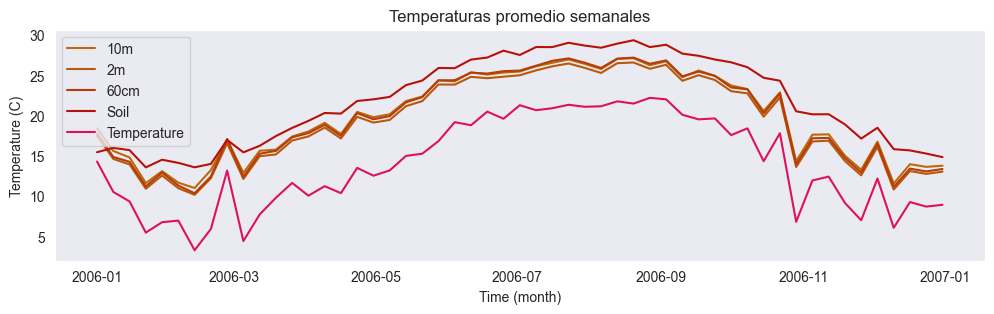

In [14]:
fig = plt.figure(figsize=(12, 3))  # Aumenta ancho, reduce altura
plt.title("Temperaturas promedio semanales")
plt.xlabel("Time (month)")
plt.ylabel("Temperature (C)")
plt.plot(average_weekly_data[["Temp @ 10m (C)"]], color='#B86B09', label="10m")
plt.plot(average_weekly_data[["Temp @ 2m (C)"]], color='#B85909', label="2m")
plt.plot(average_weekly_data[["Temp @ 60cm (C)"]], color='#B83B09', label="60cm")
plt.plot(average_weekly_data[["Soil Temp (C)"]], color='#B81109', label="Soil")
plt.plot(average_weekly_data[["Dew Point Temp (C)"]], color='#DD115E', label="Temperature")

plt.legend(loc='upper left', fontsize=10)
plt.grid()

plt.show()

In [15]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

#fig = plt.figure(figsize=(12, 2))  # Aumenta ancho, reduce altura
#plt.xlabel("Time (month)")
#plt.ylabel("Temperature (C)")
#plt.plot(average_weekly_data[["Temp @ 10m (C)"]], color='#B86B09', label="10m")
#plt.plot(average_weekly_data[["Temp @ 2m (C)"]], color='#B85909', label="2m")
#plt.plot(average_weekly_data[["Temp @ 60cm (C)"]], color='#B83B09', label="60cm")
#plt.plot(average_weekly_data[["Soil Temp (C)"]], color='#B81109', label="Soil")
#plt.plot(average_weekly_data[["Dew Point Temp (C)"]], color='#DD115E', label="Temperature")

# Añade los cuadrados con bajo contraste
#plt.axvspan(mdates.datestr2num('2006-01-01'), mdates.datestr2num('2006-03-01'), facecolor='gray', alpha=0.5)  # de enero a marzo
#plt.axvspan(mdates.datestr2num('2006-07-30'), mdates.datestr2num('2006-12-31'), facecolor='gray', alpha=0.5)  # de julio a diciembre

# Establecer límites del eje x
#plt.xlim([mdates.datestr2num('2006-01-01'), mdates.datestr2num('2006-12-31')])

#plt.legend(loc='upper left', fontsize=9)
#plt.grid()

#plt.show()

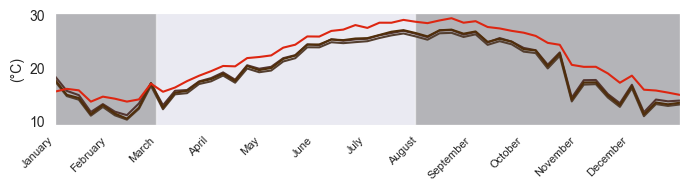

In [16]:
fig, ax = plt.subplots(figsize=(7, 2))  # Aumenta ancho, reduce altura

ax.set_ylabel("(°C)", fontsize=10)
ax.plot(average_weekly_data[["Temp @ 10m (C)"]], color='#543530', label="10m")
ax.plot(average_weekly_data[["Temp @ 2m (C)"]], color='#543F30', label="2m")
ax.plot(average_weekly_data[["Temp @ 60cm (C)"]], color='#502E0A', label="60cm")
ax.plot(average_weekly_data[["Soil Temp (C)"]], color='#DD2611', label="Soil")
#ax.plot(average_weekly_data[["Dew Point Temp (C)"]], color='#B8B305', label="Temperature")


ax.axvspan(mdates.datestr2num('2006-01-01'), mdates.datestr2num('2006-03-01'), facecolor='gray', alpha=0.5)
ax.axvspan(mdates.datestr2num('2006-07-30'), mdates.datestr2num('2006-12-31'), facecolor='gray', alpha=0.5)

ax.set_xlim([mdates.datestr2num('2006-01-01'), mdates.datestr2num('2006-12-31')])

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)


ax.grid()

plt.tight_layout()

plt.savefig('Figures/Temperature_1.png', dpi=300, transparent=True)
plt.show()

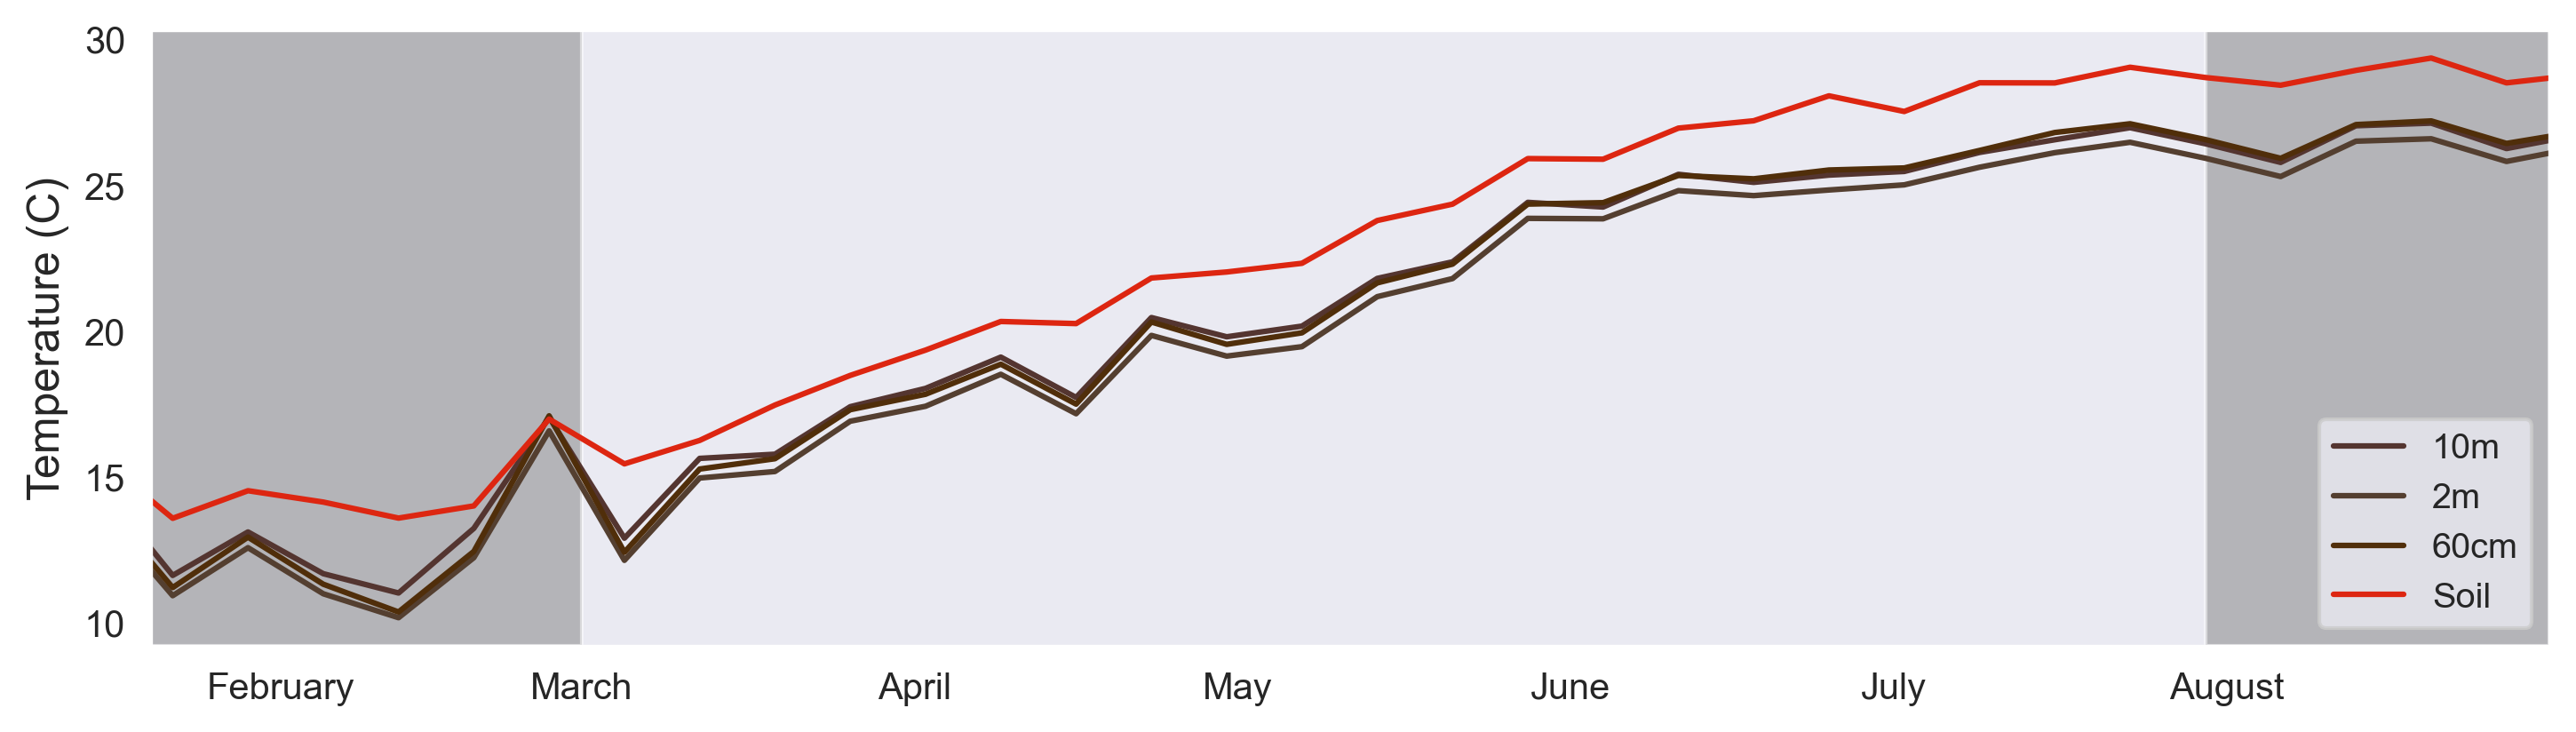

In [17]:

filtered_data = average_weekly_data[(average_weekly_data.index >= '2006-01-01') & (average_weekly_data.index <= '2006-09-20')]
fig, ax = plt.subplots(figsize=(10, 3), dpi=300)

ax.axvspan(mdates.datestr2num('2006-01-01'), mdates.datestr2num('2006-03-01'), facecolor='gray', alpha=0.5)
ax.axvspan(mdates.datestr2num('2006-07-30'), mdates.datestr2num('2006-08-31'), facecolor='gray', alpha=0.5)
plt.subplots_adjust(left=0.05, right=0.95)
ax.plot(filtered_data[["Temp @ 10m (C)"]], color='#543530', label="10m")
ax.plot(filtered_data[["Temp @ 2m (C)"]], color='#543F30', label="2m")
ax.plot(filtered_data[["Temp @ 60cm (C)"]], color='#502E0A', label="60cm")
ax.plot(filtered_data[["Soil Temp (C)"]], color='#DD2611', label="Soil")
#ax.plot(filtered_data[["Dew Point Temp (C)"]], color='#B8B305', label="Temperature")
ax.set_ylabel("Temperature (C)", fontsize=12)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_xlim([mdates.datestr2num('2006-01-20'), mdates.datestr2num('2006-08-31')])


ax.legend(loc='lower right', fontsize=9.5)
ax.grid()
plt.savefig('Figures/Temperature_2.png', dpi=300, transparent=True)
plt.show()

## S1.2 Nest height analysis

Nest height data were imported from a cleaned dataset and month labels were standardized to full month names. Nest height was converted to numeric format, and records with missing nest height or month information were excluded. Because nest height values were right-skewed, values were log-transformed prior to analysis.

Monthly differences in log-transformed nest height were tested using a linear model with month as a categorical predictor. Analysis of variance was performed on the fitted model, followed by Tukey’s honestly significant difference tests for pairwise comparisons among months. Effect size was quantified using eta squared. Model assumptions were assessed using the Shapiro–Wilk test on model residuals and Levene’s test for homogeneity of variance across months.

Predicted marginal means and 95% confidence intervals were generated on the log scale and back-transformed to the original scale for visualization. These model-based estimates were plotted together with raw nest height observations.



In [18]:

Height = 'heightnestpure.csv'

he = pd.read_csv(Height)

he = he.rename(columns={'Month ': 'month'}).rename(columns={'Nest High': 'nest_height'})
he['nest_height'] = pd.to_numeric(he['nest_height'], errors='coerce')
he

,month,nest #,nest_height
0,Feb,SD10,1.3
1,Feb,Rec1,1.3
2,Feb,Rec2,2.5
3,Feb,Rec3,2.0
4,Feb,Rec4,1.5
...,...,...,...
330,Jul,MP11,4.0
331,Jul,MP12,5.0
332,Jul,MP14,3.0
333,Jul,MP15,1.5


In [19]:
valores_unicos = he['month'].unique()
valores_unicos

array(['Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul'], dtype=object)

In [20]:
month_mapping = {
    'Feb': 'February',
    'Mar': 'March',
    'Apr': 'April',
    'May': 'May',
    'Jun': 'June',
    'Jul': 'July',
    'Aug': 'August'
}

he['month'] = he['month'].replace(month_mapping)
valores_unicos = he['month'].unique()
print(valores_unicos)

['February' 'March' 'April' 'May' 'June' 'July']


In [21]:
# Order for the months
month_order = [ 'February', 'March', 'April', 'May', 'June', 'July']
he['month'] = pd.Categorical(he['month'], categories=month_order, ordered=True)

In [22]:
he.groupby('month').describe()

C:\Users\jorge\AppData\Local\Temp\ipykernel_25000\2603704935.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  he.groupby('month').describe()


nest_height                                                
               count      mean       std   min  25%  50%    75%  max
month                                                               
February         5.0  1.720000  0.521536  1.30  1.3  1.5  2.000  2.5
March           26.0  1.914948  0.869446  1.00  1.3  1.5  2.475  4.5
April           81.0  1.946914  0.965510  0.40  1.1  1.7  2.800  4.5
May             79.0  2.117595  1.167552  0.60  1.2  1.8  2.800  6.0
June            89.0  2.554719  1.105525  0.75  1.8  2.5  3.200  6.0
July            55.0  2.655818  1.163078  0.75  1.8  2.5  3.200  7.0

In [23]:
print(he.isnull().sum())

month          0
nest #         0
nest_height    0
dtype: int64


In [24]:
print(he.groupby('month')['nest_height'].var())

month
February    0.272000
March       0.755936
April       0.932209
May         1.363177
June        1.222187
July        1.352751
Name: nest_height, dtype: float64


C:\Users\jorge\AppData\Local\Temp\ipykernel_25000\1170098612.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(he.groupby('month')['nest_height'].var())


{'whiskers': [<matplotlib.lines.Line2D at 0x223c40ac940>,
 'caps': [<matplotlib.lines.Line2D at 0x223c40ac400>,
 'boxes': [<matplotlib.lines.Line2D at 0x223c40af100>],
 'medians': [<matplotlib.lines.Line2D at 0x223c34979d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x223c3494100>],
 'means': []}

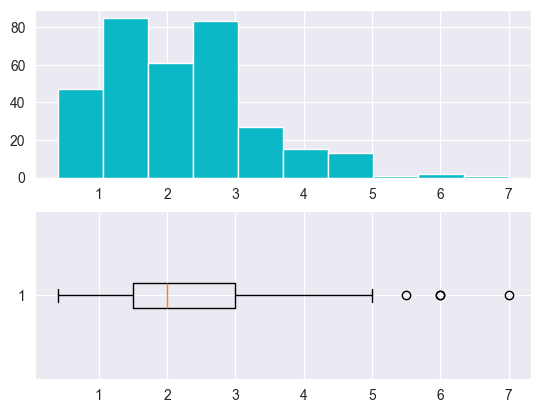

In [25]:
plt.subplot(2, 1, 1)
plt.hist(he['nest_height'], color='#0BB8C6')
plt.subplot(2, 1, 2)
plt.boxplot(he['nest_height'], vert = False)

In [26]:
he_clean = he.dropna(subset=['nest_height', 'month']).copy()
he_clean = he_clean[he_clean['month'] != 'February'].copy()
he_clean['month'] = he_clean['month'].cat.remove_unused_categories()
print(he_clean['month'].unique())

['March', 'April', 'May', 'June', 'July']
Categories (5, object): ['March' < 'April' < 'May' < 'June' < 'July']


In [27]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [28]:
he_clean['log_height'] = np.log(he_clean['nest_height'])

In [29]:
log_model2 = ols('log_height ~ month', data=he_clean).fit()

In [30]:
anova_table2 = sm.stats.anova_lm(log_model2, typ=2)
print(anova_table2)

             sum_sq     df         F   PR(>F)
month      7.105836    4.0  7.431933  0.00001
Residual  77.684924  325.0       NaN      NaN


Nest height varied significantly across the breeding season (ANOVA on log-transformed height: F₄,₃₂₅ = 7.43, p < 0.001), indicating a probably temporal shift in nest placement.

In [31]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey2 = pairwise_tukeyhsd(
    he_clean['log_height'],
    he_clean['month']
)

print(tukey2)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
 April   July   0.3564 0.0004  0.1221  0.5907   True
 April   June   0.3086 0.0005  0.1027  0.5146   True
 April  March   0.0325 0.9983 -0.2698  0.3348  False
 April    May   0.0783 0.8494 -0.1338  0.2904  False
  July   June  -0.0478 0.9794 -0.2778  0.1823  False
  July  March  -0.3239 0.0448 -0.6431 -0.0047   True
  July    May  -0.2781 0.0115 -0.5136 -0.0426   True
  June  March  -0.2761 0.0858 -0.5751  0.0229  False
  June    May  -0.2303 0.0209 -0.4376  -0.023   True
 March    May   0.0458 0.9938 -0.2574   0.349  False
----------------------------------------------------


Tukey tests showed nests built in April were significantly higher than those built later in the season (June and July). In contrast, nests in July were significantly lower than those constructed earlier in March and May.

nest height tended to decline as the breeding season progressed,

In [32]:
anova2 = sm.stats.anova_lm(log_model2, typ=2)
eta_sq2 = anova2['sum_sq']['month'] / anova2['sum_sq'].sum()
print("Eta squared (no Feb):", eta_sq2)

Eta squared (no Feb): 0.08380436632773113


In [33]:
from scipy.stats import shapiro, stats

stat, p = shapiro(log_model2.resid)
print("Shapiro p:", p)
print(he_clean.groupby('month')['log_height'].var())

Shapiro p: 0.08892303024828441
month
March    0.165044
April    0.293607
May      0.281560
June     0.208426
July     0.180873
Name: log_height, dtype: float64


C:\Users\jorge\AppData\Local\Temp\ipykernel_25000\299968085.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(he_clean.groupby('month')['log_height'].var())


In [34]:
from scipy.stats import levene

groups = [
    he_clean[he_clean['month'] == m]['log_height']
    for m in he_clean['month'].cat.categories
]

stat, p = levene(*groups)
print("Levene p:", p)

Levene p: 0.03946465795102014


In [35]:
anova2 = sm.stats.anova_lm(log_model2, typ=2)
eta_sq2 = anova2['sum_sq']['month'] / anova2['sum_sq'].sum()
print("Eta squared:", eta_sq2)

Eta squared: 0.08380436632773113


In [36]:
pred_df = pd.DataFrame({'month': he_clean['month'].cat.categories})

# Predict on log scale
pred = log_model2.get_prediction(pred_df)

pred_summary = pred.summary_frame(alpha=0.05)

pred_df['mean_log'] = pred_summary['mean']
pred_df['ci_lower_log'] = pred_summary['mean_ci_lower']
pred_df['ci_upper_log'] = pred_summary['mean_ci_upper']

In [37]:
pred_df['mean'] = np.exp(pred_df['mean_log'])
pred_df['ci_lower'] = np.exp(pred_df['ci_lower_log'])
pred_df['ci_upper'] = np.exp(pred_df['ci_upper_log'])

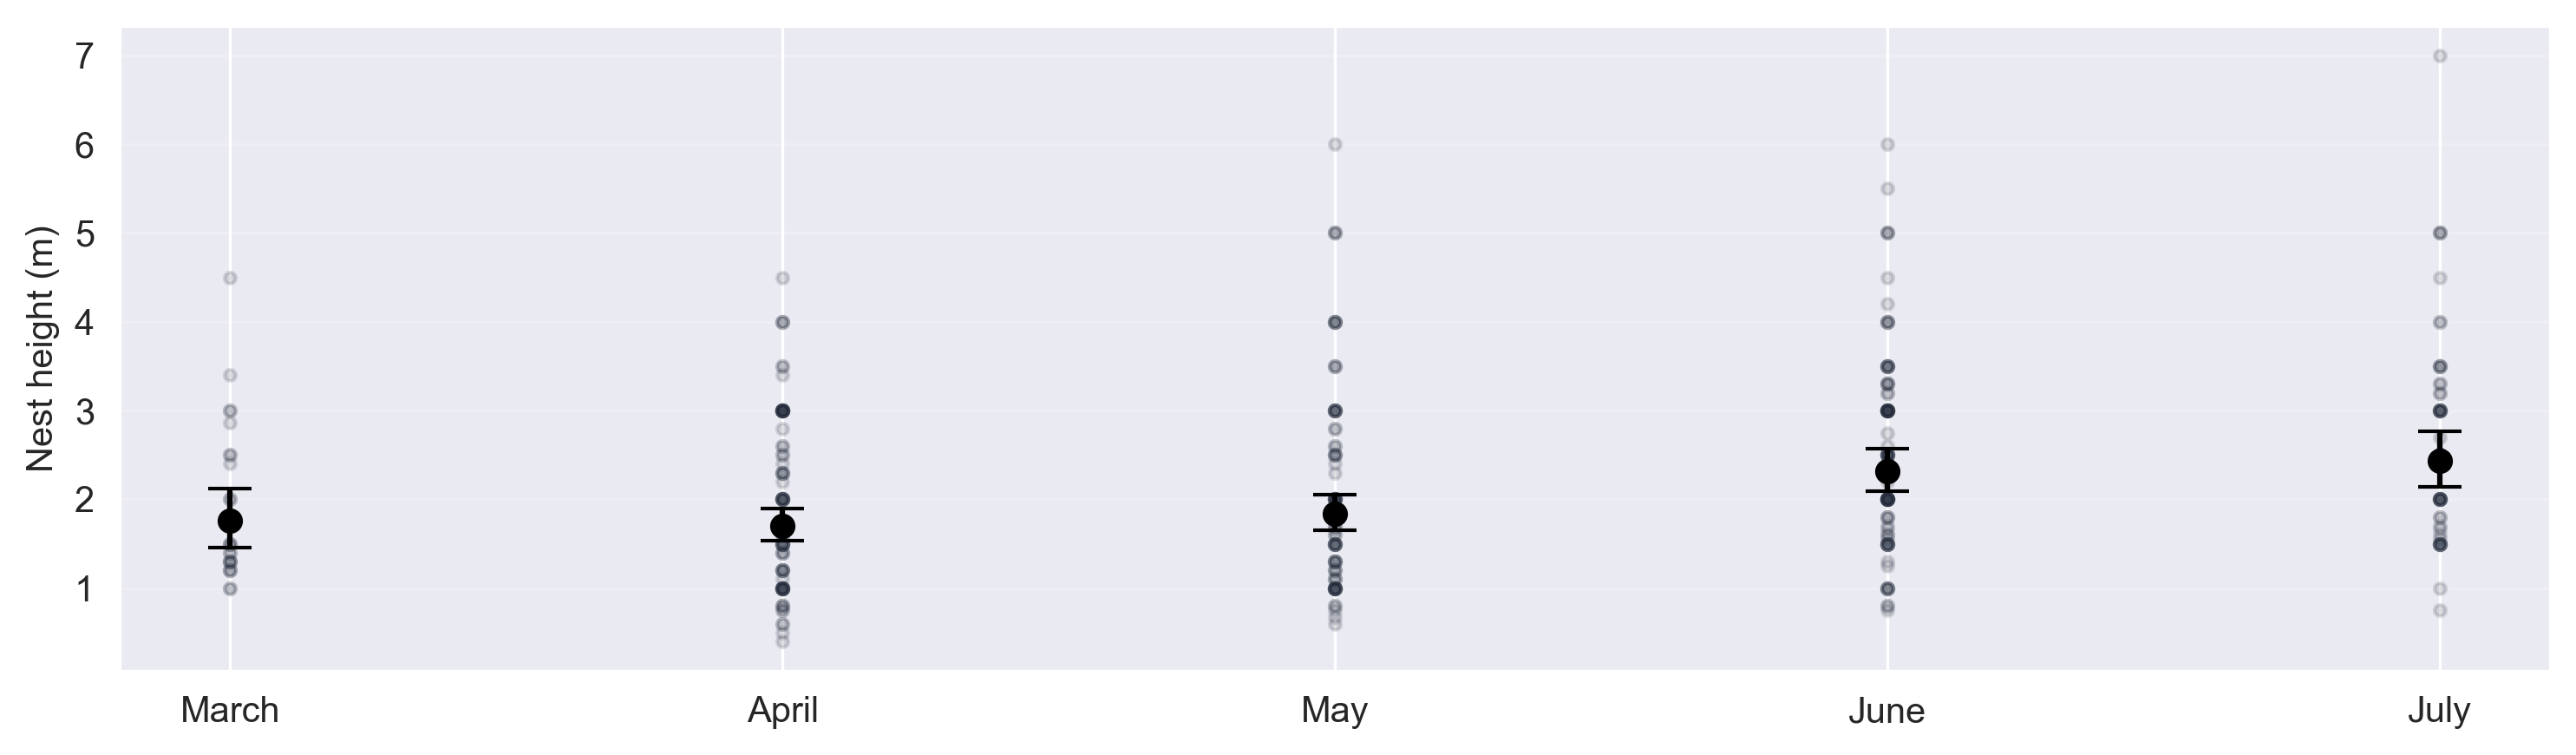

In [38]:
months = pred_df['month']
x = np.arange(len(months))

fig, ax = plt.subplots(figsize=(10, 3), dpi=300)

# Plot model mean
ax.errorbar(
    x,
    pred_df['mean'],
    yerr=[
        pred_df['mean'] - pred_df['ci_lower'],
        pred_df['ci_upper'] - pred_df['mean']
    ],
    fmt='o',
    color='black',
    capsize=6,
    label='Model mean (95% CI)',
    zorder=3
)

# Overlay raw data
for i, month in enumerate(months):
    y = he_clean[he_clean['month'] == month]['nest_height']
    ax.scatter(
        np.full(len(y), i),
        y,
        alpha=0.15,
        color='#232B3B',
        s=10,
        zorder=1
    )

ax.set_xticks(x)
ax.set_xticklabels(months)
ax.set_ylabel('Nest height (m)')
ax.set_title('')
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('Figures/HeightNEST.png', dpi=300, transparent=True)
plt.show()

## S1.3 Nest material analysis
### Nestweights

Nest material data were imported from a table containing inner material mass and outer material mass for each nest. Column names were standardized and both material variables were converted to numeric format. Total nest mass was calculated as the sum of inner and outer material masses. Records with missing values in any of these variables or in month were excluded prior to analysis.

Monthly changes in nest material mass were analysed using generalized linear models with a Gamma error distribution and a log link, appropriate for strictly positive continuous response variables. Separate models were fitted for inner material mass and total nest mass, with month included as a categorical predictor. For each response variable, the full model was compared against a null model using a likelihood-ratio test. Model fit was summarized using AIC values.

Predicted monthly means and 95% confidence intervals were extracted from the fitted models and plotted together with the observed distributions. Model adequacy was evaluated using deviance residuals, residual-versus-fitted plots, normal quantile plots of deviance residuals, dispersion estimates, and Cook’s distance values to identify potentially influential observations.


In [39]:
Nest = 'Nestweights.csv'

# Read the CSV file into a DataFrame
nest = pd.read_csv(Nest)
nest = nest.rename(columns={'Inner material': 'Inner_material', 'Outter material': 'Outter_material'})
nest['Inner_material'] = pd.to_numeric(nest['Inner_material'], errors='coerce')
nest['Outter_material'] = pd.to_numeric(nest['Outter_material'], errors='coerce')
nest['Total_Weigth'] = nest['Inner_material'] + nest['Outter_material']
nest = nest.drop('Total Weigth', axis=1)
nest

,Month,Nest,Inner_material,Outter_material,Total_Weigth
0,June,GL83,25.2,13.2,38.4
1,July,GL117,11.2,70.2,81.4
2,July,GLL116,9.9,35.3,45.2
3,July,GL127,15.0,60.3,75.3
4,April,GL20,28.6,55.8,84.4
...,...,...,...,...,...
307,April,GL44,21.5,103.9,125.4
308,May,ALS29,36.7,28.6,65.3
309,April,GL (Mechanical Aerospace),25.6,0.0,25.6
310,May,Jill Picadilly,17.4,117.2,134.6


In [40]:
# Order for the months
month_order = [ 'March', 'April', 'May', 'June', 'July']
nest['Month'] = pd.Categorical(nest['Month'], categories=month_order, ordered=True)

In [41]:
nest.groupby('Month').describe()

C:\Users\jorge\AppData\Local\Temp\ipykernel_25000\3726880854.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nest.groupby('Month').describe()


Inner_material                                                        \
               count       mean       std   min    25%   50%     75%   max   
Month                                                                        
March           38.0  27.900000  8.871972  15.3  20.20  27.6  32.575  52.6   
April           63.0  23.161905  7.958469   7.9  18.05  21.6  26.300  46.8   
May             70.0  19.211429  7.071960   9.4  14.60  17.4  23.975  41.5   
June           100.0  16.754000  5.837953   8.0  12.50  15.5  20.050  41.1   
July            41.0  13.009756  3.762433   6.0  10.20  12.2  16.600  20.7   

      Outter_material             ...                Total_Weigth             \
                count       mean  ...     75%    max        count       mean   
Month                             ...                                          
March            38.0  47.157895  ...  59.475  123.9         38.0  75.057895   
April            63.0  51.387302  ...  68.900  115.1         63.0  74.549206   
May              70.0  57.112857  ...  73.850  177.8         70.0  76.324286   
June            100.0  53.328000  ...  71.875  128.8        100.0  70.082000   
July             41.0  58.429268  ...  76.800  111.5         41.0  71.439024   

                                                    
             std   min    25%   50%     75%    max  
Month                                               
March  25.852676  31.4  58.50  72.7  82.950  150.9  
April  29.344169  25.6  51.80  68.5  92.600  153.9  
May    31.678294  25.0  51.95  72.2  96.725  187.9  
June   23.924120   8.0  54.95  66.1  86.875  138.6  
July   25.927523  23.9  49.70  70.7  90.000  129.5  

[5 rows x 24 columns]

In [42]:
print(nest.isnull().sum())

Month              0
Nest               4
Inner_material     0
Outter_material    0
Total_Weigth       0
dtype: int64


In [43]:
print(nest.groupby('Month')['Inner_material'].var())
print(nest.groupby('Month')['Outter_material'].var())
print(nest.groupby('Month')['Total_Weigth'].var())

Month
March    78.711892
April    63.337235
May      50.012621
June     34.081701
July     14.155902
Name: Inner_material, dtype: float64
Month
March     672.168450
April     835.931772
May      1011.153600
June      570.466279
July      667.392122
Name: Outter_material, dtype: float64
Month
March     668.360882
April     861.080282
May      1003.514329
June      572.363511
July      672.236439
Name: Total_Weigth, dtype: float64


C:\Users\jorge\AppData\Local\Temp\ipykernel_25000\1146514323.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(nest.groupby('Month')['Inner_material'].var())
C:\Users\jorge\AppData\Local\Temp\ipykernel_25000\1146514323.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(nest.groupby('Month')['Outter_material'].var())
C:\Users\jorge\AppData\Local\Temp\ipykernel_25000\1146514323.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and si

{'whiskers': [<matplotlib.lines.Line2D at 0x223c4760d60>,
 'caps': [<matplotlib.lines.Line2D at 0x223c4761360>,
 'boxes': [<matplotlib.lines.Line2D at 0x223c455f2b0>],
 'medians': [<matplotlib.lines.Line2D at 0x223c4761960>],
 'fliers': [<matplotlib.lines.Line2D at 0x223c4761c60>],
 'means': []}

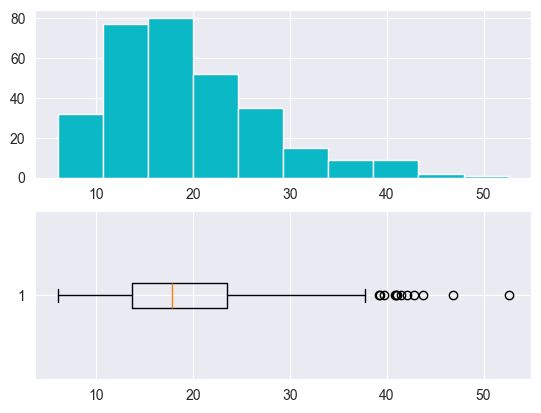

In [44]:
plt.subplot(2, 1, 1)
plt.hist(nest['Inner_material'], color='#0BB8C6')

plt.subplot(2, 1, 2)
plt.boxplot(nest['Inner_material'], vert = False)

{'whiskers': [<matplotlib.lines.Line2D at 0x223c48660b0>,
 'caps': [<matplotlib.lines.Line2D at 0x223c48666b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x223c4865db0>],
 'medians': [<matplotlib.lines.Line2D at 0x223c4866cb0>],
 'fliers': [<matplotlib.lines.Line2D at 0x223c4866fb0>],
 'means': []}

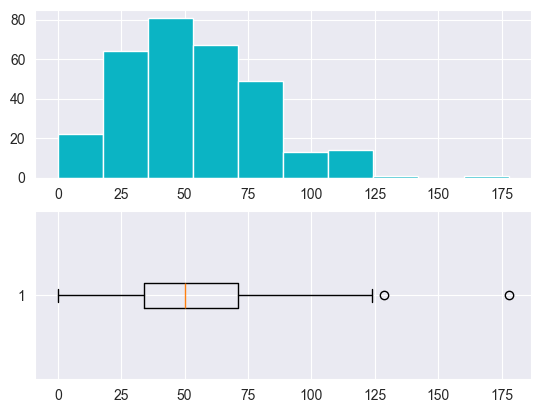

In [45]:
plt.subplot(2, 1, 1)
plt.hist(nest['Outter_material'], color='#0BB4C4')

plt.subplot(2, 1, 2)
plt.boxplot(nest['Outter_material'], vert = False)

{'whiskers': [<matplotlib.lines.Line2D at 0x223c48b2d40>,
 'caps': [<matplotlib.lines.Line2D at 0x223c48b3340>,
 'boxes': [<matplotlib.lines.Line2D at 0x223c48b2a40>],
 'medians': [<matplotlib.lines.Line2D at 0x223c43f0040>],
 'fliers': [<matplotlib.lines.Line2D at 0x223c43daa10>],
 'means': []}

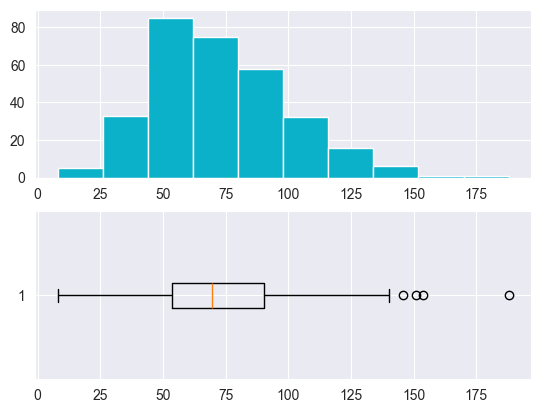

In [46]:
plt.subplot(2, 1, 1)
plt.hist(nest['Total_Weigth'], color='#0BB1C9')

plt.subplot(2, 1, 2)
plt.boxplot(nest['Total_Weigth'], vert = False)

In [47]:
nest_clean = nest.dropna(subset=['Total_Weigth', 'Month']).copy()
print((nest_clean['Total_Weigth'] <= 0).sum())


0


In [48]:
nest_clean = nest.dropna(subset=[
    'Inner_material',
    'Outter_material',
    'Total_Weigth',
    'Month'
]).copy()

print((nest_clean[['Inner_material',
                   'Outter_material',
                   'Total_Weigth']] <= 0).sum())

Inner_material     0
Outter_material    6
Total_Weigth       0
dtype: int64


In [49]:
def run_gamma(response):

    print("\n==============================")
    print("Response:", response)
    print("==============================")

    # Full model
    model = sm.GLM.from_formula(
        f'{response} ~ Month',
        data=nest_clean,
        family=sm.families.Gamma(sm.families.links.log())
    ).fit()

    # Null model
    null_model = sm.GLM.from_formula(
        f'{response} ~ 1',
        data=nest_clean,
        family=sm.families.Gamma(sm.families.links.log())
    ).fit()

    # Likelihood ratio test
    lr_stat = 2 * (model.llf - null_model.llf)
    df_diff = model.df_model
    from scipy.stats import chi2
    p_value = chi2.sf(lr_stat, df_diff)

    print("LR p-value:", p_value)
    print("AIC:", model.aic)

    return model

In [50]:
model_inner = run_gamma('Inner_material')
#model_outer = run_gamma('Outter_material')
model_total = run_gamma('Total_Weigth')


Response: Inner_material
LR p-value: 2.925458703882108e-25
AIC: 2012.4154757759325

Response: Total_Weigth
LR p-value: 0.612106066561696
AIC: 2933.7257528262658


C:\Users\jorge\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
C:\Users\jorge\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
C:\Users\jorge\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(
C:\Users\jorge\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0

Inner nest material mass varied across the breeding season (likelihood-ratio test: p < 0.001). Relative to March (reference month), inner material mass declined progressively through the season, with significantly lower values in April, May, June, and July (all p ≤ 0.008). The largest reduction occurred in July, indicating that nests constructed later in the season contained probably less inner structural material.

In [51]:
print(model_inner.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         Inner_material   No. Observations:                  312
Model:                            GLM   Df Residuals:                      307
Model Family:                   Gamma   Df Model:                            4
Link Function:                    log   Scale:                         0.11654
Method:                          IRLS   Log-Likelihood:                -1001.2
Date:                Mon, 09 Mar 2026   Deviance:                       33.872
Time:                        14:16:32   Pearson chi2:                     35.8
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3487
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          3.3286      0.055     60.

Together, these results indicate that while the composition of nests changes seasonally, with decreasing investment in inner materials later in the season, the total amount of material used in nest construction remains broadly stable.

In [52]:
np.exp(model_inner.params)

Intercept         27.900000
Month[T.April]     0.830176
Month[T.May]       0.688582
Month[T.June]      0.600502
Month[T.July]      0.466300
dtype: float64

In [53]:
#print("Pseudo R²:", 1 - model_inner.deviance / model_inner.null_deviance)

In [54]:
pred_df = pd.DataFrame({'Month': nest_clean['Month'].cat.categories})

pred = model_inner.get_prediction(pred_df)
pred_summary = pred.summary_frame()

pred_df['mean'] = pred_summary['mean']
pred_df['lower'] = pred_summary['mean_ci_lower']
pred_df['upper'] = pred_summary['mean_ci_upper']

C:\Users\jorge\AppData\Local\Temp\ipykernel_25000\1492845003.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


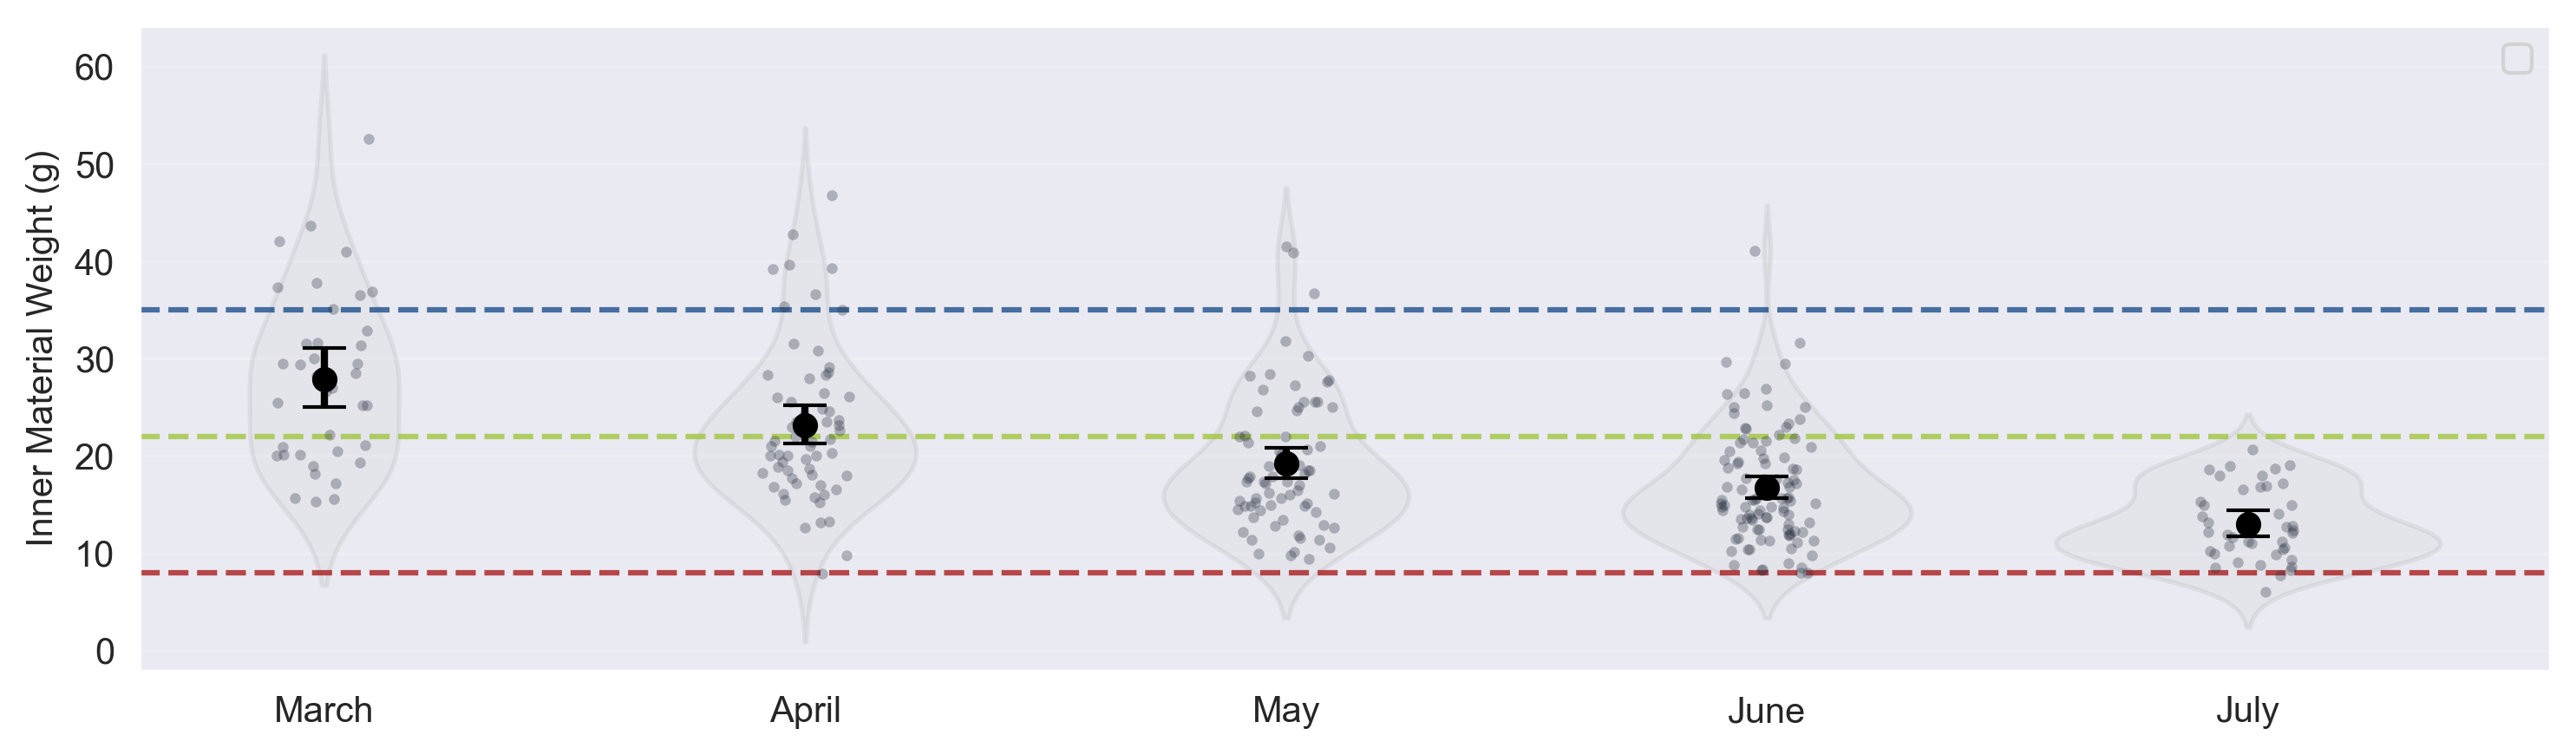

In [55]:
fig, ax = plt.subplots(figsize=(10, 3), dpi=300)

# Violin (distribución real)
sn.violinplot(
    data=nest_clean,
    x='Month',
    y='Inner_material',
    color="#B0B3B8",
    inner=None,
    alpha=0.1,
    ax=ax
)

# Puntos reales
sn.stripplot(
    data=nest_clean,
    x='Month',
    y='Inner_material',
    color='#232B3B',
    alpha=0.3,
    size=3,
    jitter=True,
    ax=ax
)

# Modelo (media + CI)
x_positions = np.arange(len(pred_df['Month']))

ax.errorbar(
    x_positions,
    pred_df['mean'],
    yerr=[
        pred_df['mean'] - pred_df['lower'],
        pred_df['upper'] - pred_df['mean']
    ],
    fmt='o',
    color='black',
    capsize=6,
    linewidth=2,
#    label='Gamma GLM mean (95% CI)',
    zorder=5
)

ax.set_ylabel('Inner Material Weight (g)')
ax.set_xlabel('')
ax.grid(axis='y', alpha=0.2)
ax.legend()
ax.axhline(8, color='#a00000', linestyle='--', alpha=0.7)
ax.axhline(22, color='#98c127', linestyle='--', alpha=0.7)
ax.axhline(35, color='#003a7d', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('Figures/Inner_Material_Weight.png', dpi=300, transparent=True)
plt.show()

In [56]:
summary_stats = nest_clean.groupby('Month')['Inner_material'].agg(['mean','var'])
print(summary_stats)

            mean        var
Month                      
March  27.900000  78.711892
April  23.161905  63.337235
May    19.211429  50.012621
June   16.754000  34.081701
July   13.009756  14.155902


C:\Users\jorge\AppData\Local\Temp\ipykernel_25000\1853080564.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = nest_clean.groupby('Month')['Inner_material'].agg(['mean','var'])


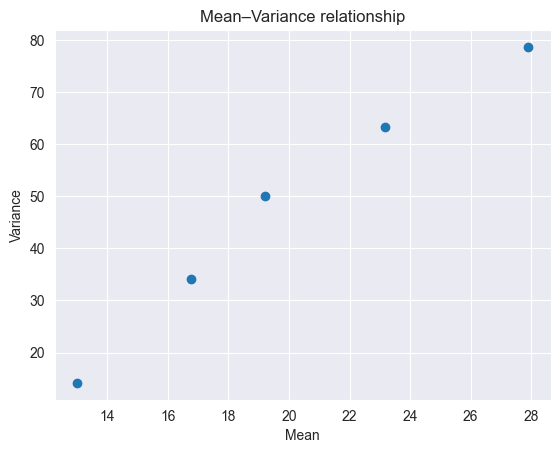

In [57]:
plt.scatter(summary_stats['mean'], summary_stats['var'])
plt.xlabel("Mean")
plt.ylabel("Variance")
plt.title("Mean–Variance relationship")
plt.show()

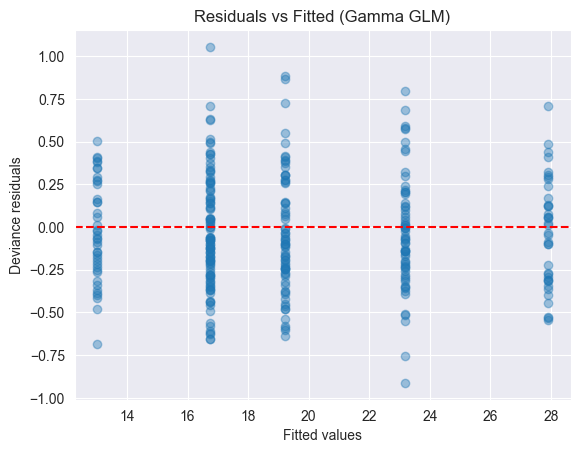

In [58]:
fitted = model_inner.fittedvalues
resid_dev = model_inner.resid_deviance

plt.scatter(fitted, resid_dev, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Deviance residuals")
plt.title("Residuals vs Fitted (Gamma GLM)")
plt.show()

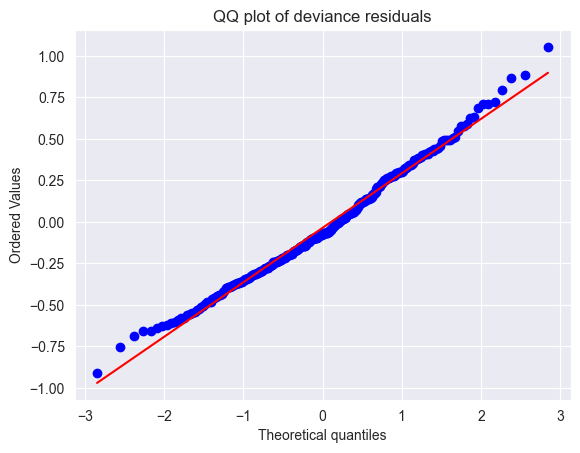

Dispersion: 0.11653778362628026


In [59]:
import scipy.stats as stats
stats.probplot(resid_dev, dist="norm", plot=plt)
plt.title("QQ plot of deviance residuals")
plt.show()
print("Dispersion:", model_inner.scale)

In [60]:
influence = model_inner.get_influence()
cooks = influence.cooks_distance[0]

print("Points with Cook's D > 4/n:",
      sum(cooks > 4/len(nest_clean)))

Points with Cook's D > 4/n: 22


## S1.4. Egg mass and clutch size analysis

Egg mass data were imported from a multi-year dataset. Records with missing egg mass values or invalid non-numeric entries were excluded. Egg masses below a biologically implausible threshold were also removed prior to analysis. Nest-level summaries were then calculated by grouping records by date and nest identity. For each nest, total egg mass, clutch size, and breeding month were extracted. Mean egg mass per nest was computed as total egg mass divided by clutch size.

Monthly differences in clutch size were analysed using a generalized linear model with a Poisson error distribution. Monthly differences in mean egg mass and total egg mass were analysed using generalized linear models with a Gamma error distribution and log link. In addition, an interaction model was fitted to test whether the relationship between clutch size and mean egg mass varied among months.

Predicted means and 95% confidence intervals were generated for month-specific effects and for the month-by-clutch-size interaction. These predictions were visualized alongside raw nest-level observations. Pairwise contrasts among months were evaluated using model-based linear hypothesis tests. Model adequacy was assessed by examining mean–variance relationships, deviance residuals, residual histograms, and dispersion statistics.


In [61]:

Egg = 'eggmassyears.csv'

eg = pd.read_csv(Egg)
eg = eg.rename(columns={'clutch size': 'clutch_size'})
eg = eg.dropna(subset=['massegg'])
eg = eg[eg['massegg'] != 'x']
eg['massegg'] = eg['massegg'].astype(float)
eg = eg[eg['massegg'] > 2.48]
eg.head()

,date,year,month,Idnest,massegg,number,clutch_size
0,24-Jun-06,2006,Jun,ALS1,4.80,A,3
1,24-Jun-06,2006,Jun,ALS1,4.80,B,3
2,24-Jun-06,2006,Jun,ALS1,4.65,C,3
3,24-Jun-06,2006,Jun,ALS,4.80,A,3
4,24-Jun-06,2006,Jun,ALS,4.60,B,3


In [62]:
print(eg.columns)

Index(['date', 'year', 'month', 'Idnest', 'massegg', 'number', 'clutch_size'], dtype='object')


In [63]:
nest_data = eg.groupby(['date', 'Idnest']).agg(
    masstotal=('massegg', 'sum'),
    Clutch_Size=('massegg', 'size'),
    month=('month', 'first')
).reset_index()

In [64]:
nest_level = eg.groupby(['date', 'Idnest']).agg(
    Clutch_Size=('massegg', 'size'),
    month=('month', 'first')
).reset_index()

nest_level.head()
nest_level.shape

(491, 4)

In [65]:
month_mapping = {
    'Mar': 'March',
    'Apr': 'April',
    'May': 'May',
    'Jun': 'June',
    'Jul': 'July'
}

nest_data['month'] = nest_data['month'].replace(month_mapping)

month_order = ['March', 'April', 'May', 'June', 'July']
nest_data['month'] = pd.Categorical(
    nest_data['month'],
    categories=month_order,
    ordered=True
)

In [66]:
nest_data['mean_egg_mass'] = (
    nest_data['masstotal'] / nest_data['Clutch_Size']
)
nest_data

,date,Idnest,masstotal,Clutch_Size,month,mean_egg_mass
0,1-Apr-06,JU 1,13.65,3,April,4.550000
1,1-Apr-06,JU1,13.65,3,April,4.550000
2,1-Jul-05,GL120,12.80,3,July,4.266667
3,1-Jul-05,GL124,8.60,2,July,4.300000
4,1-Jul-06,ALS11,13.95,3,July,4.650000
...,...,...,...,...,...,...
486,9-Jun-06,MP,13.20,3,June,4.400000
487,9-May-05,GL62,14.10,3,May,4.700000
488,9-May-06,ALS34,13.80,3,May,4.600000
489,9-May-06,MP 03,13.40,3,May,4.466667


In [67]:

nest_data.groupby('month').describe()

C:\Users\jorge\AppData\Local\Temp\ipykernel_25000\3737864258.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nest_data.groupby('month').describe()


masstotal                                                          \
          count       mean       std   min     25%    50%    75%    max   
month                                                                     
March      24.0  11.247917  3.768245  3.00   9.600  11.50  12.75  19.20   
April     113.0  12.953982  5.328613  2.55   9.000  13.05  15.40  40.70   
May       149.0  13.348188  5.289007  3.10  10.300  13.50  15.70  42.70   
June      144.0  13.749583  4.651705  2.60  11.375  13.85  16.40  31.60   
July       61.0  11.749836  4.431416  3.80   8.550  12.65  14.15  25.25   

      Clutch_Size            ...           mean_egg_mass                      \
            count      mean  ...  75%  max         count      mean       std   
month                        ...                                               
March        24.0  2.875000  ...  3.0  4.0          24.0  3.857986  0.479391   
April       113.0  3.008850  ...  4.0  8.0         113.0  4.309250  0.458029   
May         149.0  2.993289  ...  4.0  8.0         149.0  4.443915  0.504852   
June        144.0  3.041667  ...  4.0  8.0         144.0  4.497205  0.544322   
July         61.0  2.737705  ...  3.0  6.0          61.0  4.265861  0.399072   

                                                     
        min       25%       50%       75%       max  
month                                                
March  3.00  3.525000  3.850000  4.233333  4.800000  
April  2.55  4.000000  4.350000  4.600000  5.450000  
May    3.10  4.125000  4.500000  4.783333  5.616667  
June   2.60  4.145833  4.550000  4.850000  5.737500  
July   3.40  4.046667  4.233333  4.475000  5.312500  

[5 rows x 24 columns]

In [68]:
nest_data['month'].value_counts()

month
May      149
June     144
April    113
July      61
March     24
Name: count, dtype: int64

In [69]:
model_clutch = sm.GLM.from_formula(
    'Clutch_Size ~ month',
    data=nest_data,
    family=sm.families.Poisson()
).fit()

print(model_clutch.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            Clutch_Size   No. Observations:                  491
Model:                            GLM   Df Residuals:                      486
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -806.81
Date:                Mon, 09 Mar 2026   Deviance:                       178.28
Time:                        14:16:36   Pearson chi2:                     175.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.003134
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.0561      0.120      8.

Clutch size did not vary significantly across the breeding season (Poisson GLM; all monthly contrasts p ≥ 0.66). Model coefficients indicated only minor differences among months, and the very low R² suggests that breeding month explains little variation in clutch size.

In [70]:
model_mean = sm.GLM.from_formula(
    'mean_egg_mass ~ month',
    data=nest_data,
    family=sm.families.Gamma(sm.families.links.log())
).fit()

print(model_mean.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          mean_egg_mass   No. Observations:                  491
Model:                            GLM   Df Residuals:                      486
Model Family:                   Gamma   Df Model:                            4
Link Function:                    log   Scale:                        0.012655
Method:                          IRLS   Log-Likelihood:                -355.92
Date:                Mon, 09 Mar 2026   Deviance:                       6.4669
Time:                        14:16:37   Pearson chi2:                     6.15
No. Iterations:                     6   Pseudo R-squ. (CS):            0.08842
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.3501      0.023     58.

C:\Users\jorge\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In contrast, mean egg mass increased significantly after March (Gamma GLM with log link). Eggs laid in April, May, June, and July were all significantly heavier than those laid in March (all p < 0.001).

In [71]:
nest_data['date'] = pd.to_datetime(nest_data['date'])
nest_data['day_of_year'] = nest_data['date'].dt.dayofyear
nest_data['month_number'] = nest_data['date'].dt.month

C:\Users\jorge\AppData\Local\Temp\ipykernel_25000\2283490594.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  nest_data['date'] = pd.to_datetime(nest_data['date'])


In [72]:
pred_df = pd.DataFrame({
    'month': nest_data['month'].cat.categories
})

pred = model_mean.get_prediction(pred_df)
pred_summary = pred.summary_frame()

pred_df['mean'] = pred_summary['mean']
pred_df['lower'] = pred_summary['mean_ci_lower']
pred_df['upper'] = pred_summary['mean_ci_upper']

In [73]:
months_to_plot = ['March', 'April', 'May', 'June', 'July']
month_nums = range(3, 8)

positions = [month_num * 30 - 15 for month_num in month_nums]

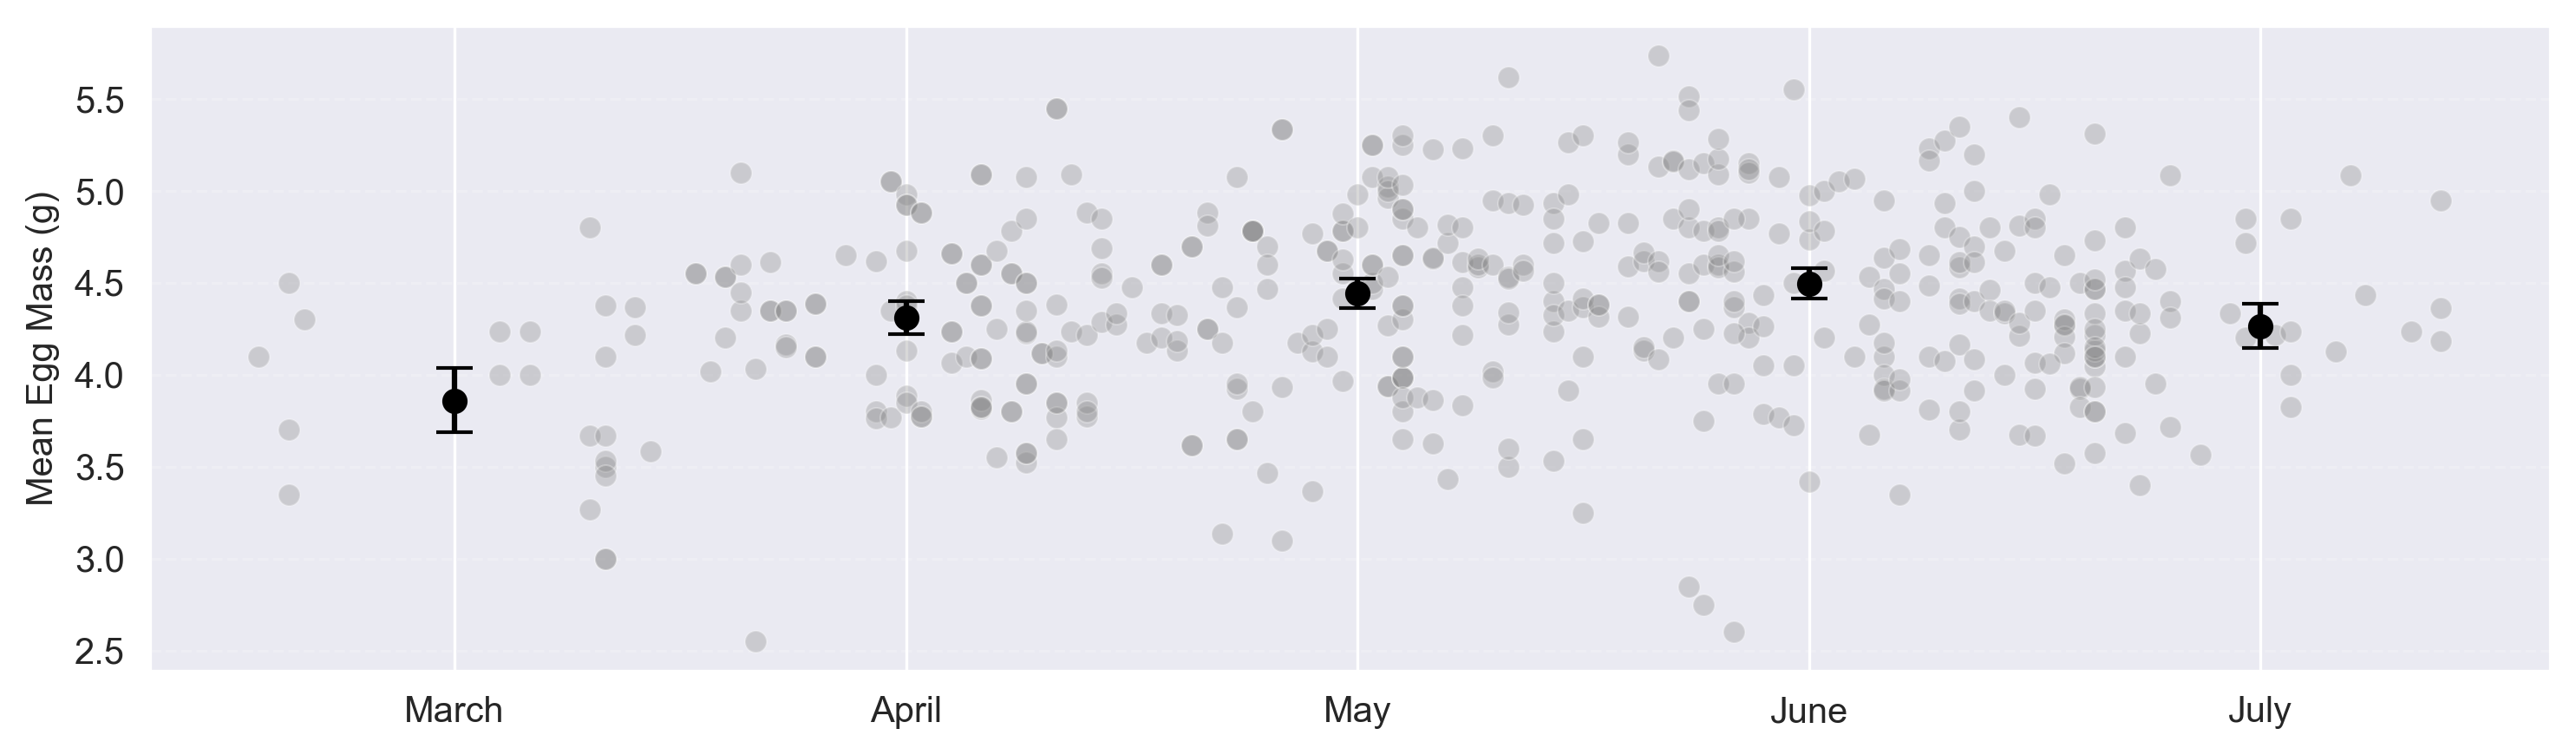

In [74]:
fig, ax = plt.subplots(figsize=(10, 3), dpi=300)

# Scatter real (nest-level mean egg mass)
sn.scatterplot(
    x='day_of_year',
    y='mean_egg_mass',
    data=nest_data,
    color='gray',
    alpha=0.3,
    zorder=2,
    ax=ax
)

# Boxplots por mes
'''
box_data = [
    nest_data[nest_data['month_number'] == month]['mean_egg_mass'].dropna().values
    for month in month_nums
]

bp = plt.boxplot(
    box_data,
    positions=positions,
    widths=6,
    patch_artist=True,
    boxprops=dict(facecolor='#888B91', color='black'),
    medianprops=dict(color='black'),
    sym=''
)
'''
# Agregar media predictiva + CI
for pos, mean, lower, upper in zip(positions, pred_df['mean'], pred_df['lower'], pred_df['upper']):

    ax.errorbar(
        pos,
        mean,
        yerr=[[mean - lower], [upper - mean]],
        fmt='o',
        color='black',
        capsize=5,
        zorder=5
    )

plt.xticks(ticks=positions, labels=months_to_plot)
plt.ylabel('Mean Egg Mass (g)')
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.savefig('MeanEggMass_Model.png', dpi=300, transparent=True)
plt.show()

In [75]:
from itertools import combinations

months = nest_data['month'].cat.categories[1:]  # exclude baseline
comparisons = list(combinations(months, 2))

for m1, m2 in comparisons:
    print(f"\n{m1} vs {m2}")
    print(model_mean.t_test(f"month[T.{m1}] - month[T.{m2}]"))



April vs May
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0308      0.014     -2.193      0.028      -0.058      -0.003

April vs June
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.0427      0.014     -3.020      0.003      -0.070      -0.015

April vs July
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.0101      0.018      0.566      0.571      -0.025       0.045

May vs 

C:\Users\jorge\AppData\Local\Temp\ipykernel_25000\3460378542.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = nest_data.groupby('month')['mean_egg_mass'].agg(['mean','var']).reset_index()


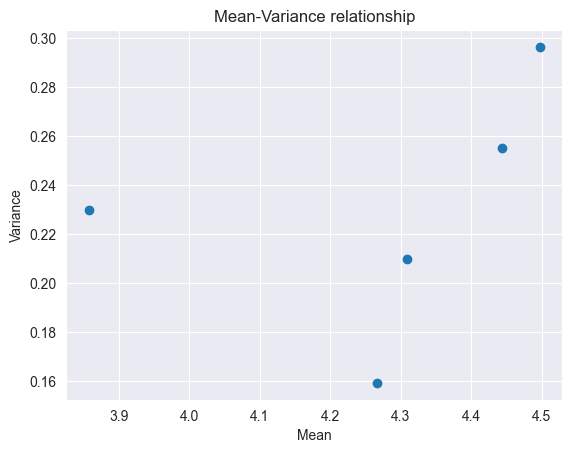

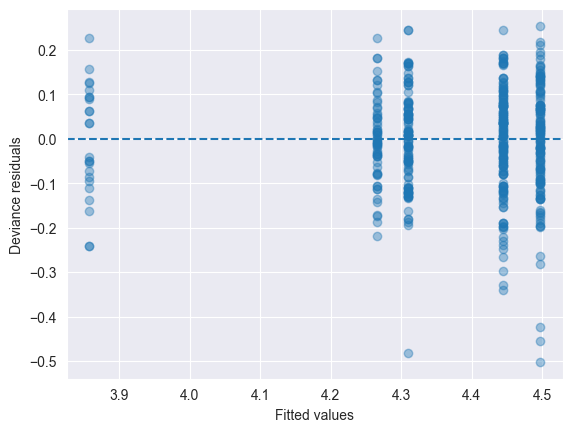

In [76]:
group_stats = nest_data.groupby('month')['mean_egg_mass'].agg(['mean','var']).reset_index()

plt.scatter(group_stats['mean'], group_stats['var'])
plt.xlabel("Mean")
plt.ylabel("Variance")
plt.title("Mean-Variance relationship")
plt.show()

resid = model_mean.resid_deviance
fitted = model_mean.fittedvalues

plt.scatter(fitted, resid, alpha=0.4)
plt.axhline(0, linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Deviance residuals")
plt.show()

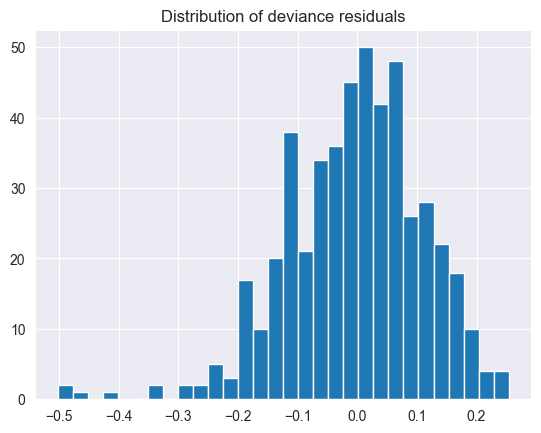

Dispersion: 0.012655475829366464


In [77]:
plt.hist(resid, bins=30)
plt.title("Distribution of deviance residuals")
plt.show()
dispersion = model_mean.pearson_chi2 / model_mean.df_resid
print("Dispersion:", dispersion)

In [78]:
model_total = sm.GLM.from_formula(
    'masstotal ~ month',
    data=nest_data,
    family=sm.families.Gamma(sm.families.links.log())
).fit()

print(model_total.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              masstotal   No. Observations:                  491
Model:                            GLM   Df Residuals:                      486
Model Family:                   Gamma   Df Model:                            4
Link Function:                    log   Scale:                         0.14336
Method:                          IRLS   Log-Likelihood:                -1474.7
Date:                Mon, 09 Mar 2026   Deviance:                       78.037
Time:                        14:16:38   Pearson chi2:                     69.7
No. Iterations:                     6   Pseudo R-squ. (CS):            0.02295
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.4202      0.077     31.

C:\Users\jorge\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


However, the overall explanatory power of month was low (pseudo-R² ≈ 0.023), indicating that seasonal timing explains only a small portion of the variation in total clutch mass. So it was not used in that studio, but we wanted to keep it for reviewing processing.

In [79]:
eg_model = eg[['massegg', 'month', 'clutch_size', 'Idnest']].dropna().copy()
eg_model['month'] = eg_model['month'].replace(month_mapping)
eg_model

,massegg,month,clutch_size,Idnest
0,4.80,June,3,ALS1
1,4.80,June,3,ALS1
2,4.65,June,3,ALS1
3,4.80,June,3,ALS
4,4.60,June,3,ALS
...,...,...,...,...
1469,4.50,July,3,GL142
1470,4.50,July,4,SD317
1471,4.60,July,4,SD317
1472,5.10,July,4,SD317


In [80]:

# create log response
eg_model['log_massegg'] = np.log(eg_model['massegg'])

In [99]:
model_mean2 = sm.GLM.from_formula(
    'mean_egg_mass ~ month * Clutch_Size',
    data=nest_data,
    family=sm.families.Gamma(sm.families.links.log())
).fit()

print(model_mean2.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:          mean_egg_mass   No. Observations:                  491
Model:                            GLM   Df Residuals:                      481
Model Family:                   Gamma   Df Model:                            9
Link Function:                    log   Scale:                        0.012552
Method:                          IRLS   Log-Likelihood:                -350.42
Date:                Mon, 09 Mar 2026   Deviance:                       6.3265
Time:                        14:26:07   Pearson chi2:                     6.04
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1096
Covariance Type:            nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

C:\Users\jorge\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [100]:
clutch_min = nest_data['Clutch_Size'].min()
clutch_max = nest_data['Clutch_Size'].max()

clutch_range = np.arange(clutch_min, clutch_max + 1)

months = nest_data['month'].cat.categories

# Build prediction grid
pred_grid = pd.DataFrame([
    (m, cs) for m in months for cs in clutch_range
], columns=['month', 'Clutch_Size'])

# Get predictions
pred = model_mean2.get_prediction(pred_grid)
pred_summary = pred.summary_frame()

pred_grid['mean'] = pred_summary['mean']
pred_grid['lower'] = pred_summary['mean_ci_lower']
pred_grid['upper'] = pred_summary['mean_ci_upper']

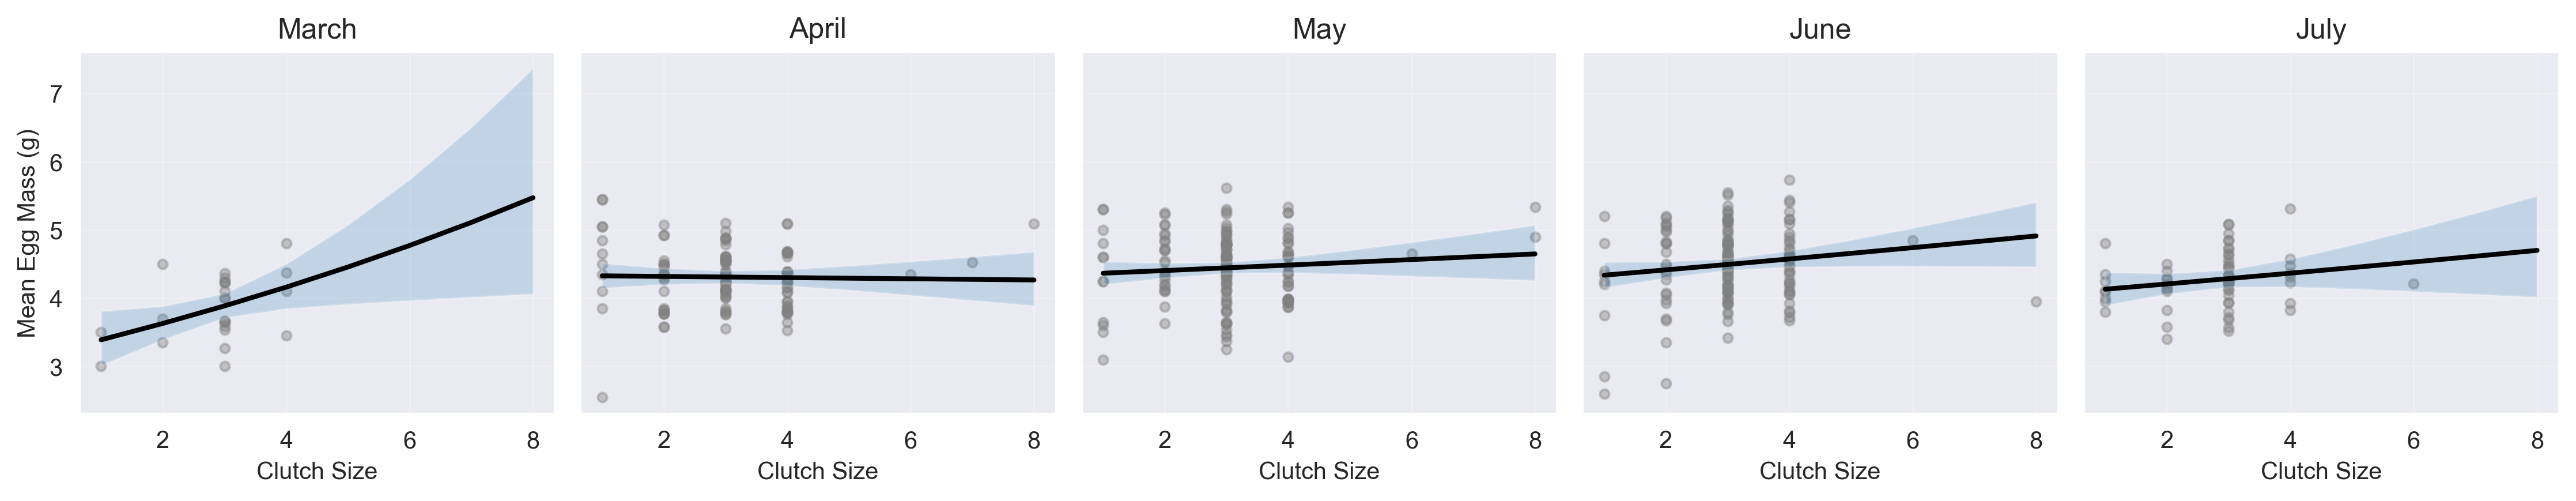

In [101]:
months = nest_data['month'].cat.categories

fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True, dpi=300)

for ax, month in zip(axes, months):

    # Subset observed data
    obs = nest_data[nest_data['month'] == month]

    # Subset predictions
    pred_sub = pred_grid[pred_grid['month'] == month]

    # Raw data points
    ax.scatter(
        obs['Clutch_Size'],
        obs['mean_egg_mass'],
        color='gray',
        alpha=0.4,
        s=15
    )

    # Predicted line
    ax.plot(
        pred_sub['Clutch_Size'],
        pred_sub['mean'],
        color='black',
        linewidth=2
    )

    # CI ribbon
    ax.fill_between(
        pred_sub['Clutch_Size'],
        pred_sub['lower'],
        pred_sub['upper'],
        alpha=0.2
    )

    ax.set_title(month)
    ax.set_xlabel("Clutch Size")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("Mean Egg Mass (g)")

plt.tight_layout()
plt.savefig("EggMass_Interaction_Panels.png", dpi=300, bbox_inches='tight')
plt.show()

## Variable glossary
- **nest_height**: the measured nest height (m) recorded in `heightnestpure.csv`, used to assess seasonal shifts in nest placement across the breeding season.
- **month**: standardized month labels derived from the source dataset so that statistical models compare February through July consistently.
- **log_height**: the natural logarithm of `nest_height`, used in linear models to reduce skewness and improve model assumptions.
- **Inner_material**, **Outter_material**, **Total_Weigth**: nest material mass components (g) from `Nestweights.csv`. `Total_Weigth` is calculated as `Inner_material + Outter_material` and used in Gamma GLMs describing seasonal changes in nest construction mass.
- **massegg**: individual egg-mass observations (g) recorded in `eggmassyears.csv`.
- **masstotal**: clutch-level sum of `massegg` values for each nest, calculated by grouping observations by `date` and `Idnest`.
- **Clutch_Size**: the number of eggs recorded per nest (`Idnest`), representing clutch size and modeled using Poisson GLMs to examine seasonal variation.
- **mean_egg_mass**: the average egg mass per nest calculated as `masstotal / Clutch_Size`, modeled with Gamma GLMs to evaluate seasonal changes in per-egg investment.
- **Idnest**: unique nest identifier linking egg-level observations to nest-level summaries and predictions.
- **date**: calendar date associated with each nesting record, used to derive temporal variables.
- **day_of_year**: Julian day derived from `date`, used for visualizing seasonal patterns in egg mass across the breeding season.
- **month_number**: numeric representation of month extracted from `date`, used for ordering and visualization in seasonal plots.